In [1]:
# Cài đặt thư viện (nếu chưa có)
# !pip install lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load dữ liệu đã xử lý ở Buổi 1
df = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_rfm.csv')

# Convert lại cột ngày tháng (vì CSV không lưu định dạng datetime)
df['created_date'] = pd.to_datetime(df['created_date'])
df['last_active_date'] = pd.to_datetime(df['last_active_date'])

print(f"Data Loaded: {df.shape}")

Data Loaded: (80000, 16)


In [2]:
# 2. Chuẩn bị dữ liệu cho BG/NBD Model

# Ngày chốt dữ liệu (Snapshot date)
current_date = df['last_active_date'].max()

# Tính toán các biến theo đơn vị TUẦN (Weeks)
df['T_weeks'] = ((current_date - df['created_date']).dt.days / 7)
df['recency_weeks'] = ((df['last_active_date'] - df['created_date']).dt.days / 7)

# Frequency: Lifelines yêu cầu số lần mua LẶP LẠI (Repeat transactions)
# Ta dùng nums_service. Nếu khách chỉ có 1 service -> coi như chưa lặp lại (freq=0)
# (Đây là giả định cho bài lab vì không có transaction log chi tiết)
df['frequency_cal'] = df['nums_service'].apply(lambda x: x - 1 if x > 0 else 0)

# Loại bỏ các dữ liệu nhiễu (Ví dụ: Active date < Created date do lỗi hệ thống)
df = df[df['recency_weeks'] <= df['T_weeks']]
df = df[df['T_weeks'] > 0] # Khách hàng phải tồn tại ít nhất 1 tuần

# Monetary Value (Giá trị trung bình mỗi giao dịch)
# Ta dùng balance/nums_service để ước lượng giá trị trung bình mỗi service mang lại
df['monetary_value'] = df['balance'] / df['nums_service']
df['monetary_value'] = df['monetary_value'].fillna(0)
# Loại bỏ giá trị âm hoặc 0 (Gamma-Gamma yêu cầu monetary > 0)
df = df[df['monetary_value'] > 0]

print("Dữ liệu sẵn sàng cho mô hình xác suất:")
print(df[['full_name', 'frequency_cal', 'recency_weeks', 'T_weeks', 'monetary_value']].head())

Dữ liệu sẵn sàng cho mô hình xác suất:
          full_name  frequency_cal  recency_weeks  T_weeks  monetary_value
0       Đặng Văn Vũ              7           5.00    17.71     22163250.50
1      Bùi Hữu Phúc              1         197.86   204.71       963708.00
2        Lê Văn Mai              7          27.29   225.86     38116468.12
3  Dương Trần Nhiên              2         159.43   176.43     16871833.67
4    Dương Thu Linh              2           1.86   153.29     13510810.67


--- BG/NBD Model Summary ---
       coef  se(coef)  lower 95% bound  upper 95% bound
r      0.40      0.00             0.40             0.41
alpha  3.02      0.03             2.95             3.08
a      0.69      0.01             0.68             0.70
b      1.97      0.02             1.94             2.00


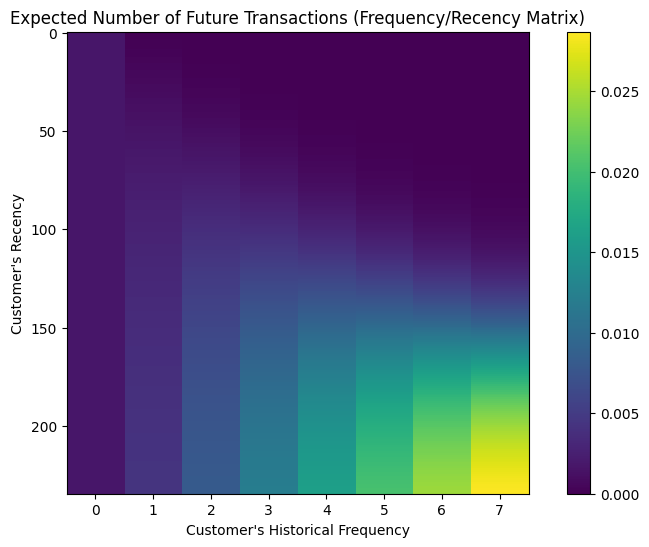

Top 5 khách hàng dự kiến giao dịch nhiều nhất 3 tháng tới:
              full_name  predicted_purchases_12weeks
41167       Mai Anh Anh                        14.46
28399  Nguyễn Trần Dũng                        14.46
78090  Phạm Hoàng Duyên                        14.05
79119        Mai Đức Tú                        14.00
18245   Hoàng Thanh Lan                        13.66


In [3]:
# 3. BG/NBD Model: Dự báo số giao dịch tương lai

bgf = BetaGeoFitter(penalizer_coef=0.01) # penalizer giúp tránh overfitting
df.loc[df['frequency_cal'] == 0, 'recency_weeks'] = 0
bgf.fit(df['frequency_cal'], df['recency_weeks'], df['T_weeks'])

print("--- BG/NBD Model Summary ---")
print(bgf.summary)

# Trực quan hóa ma trận Frequency/Recency
from lifetimes.plotting import plot_frequency_recency_matrix
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(bgf)
plt.title("Expected Number of Future Transactions (Frequency/Recency Matrix)")
plt.show()

# --- DỰ BÁO ---
# Dự báo số giao dịch trong 12 tuần tới (3 tháng)
t_future = 12
df['predicted_purchases_12weeks'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t_future, df['frequency_cal'], df['recency_weeks'], df['T_weeks']
)

print("Top 5 khách hàng dự kiến giao dịch nhiều nhất 3 tháng tới:")
print(df.sort_values('predicted_purchases_12weeks', ascending=False)[['full_name', 'predicted_purchases_12weeks']].head())

In [4]:
# 4. Gamma-Gamma Model: Dự báo giá trị trung bình

# Kiểm tra giả định độc lập (Correlation check)
# Nếu correlation quá mạnh (ví dụ > 0.5), mô hình này có thể không chính xác
corr = df[['frequency_cal', 'monetary_value']].corr().iloc[0,1]
print(f"Tương quan giữa Frequency và Monetary: {corr:.4f}")

# Train Gamma-Gamma
ggf = GammaGammaFitter(penalizer_coef=0.01)
# Chỉ train trên những khách hàng đã có giao dịch lặp lại (freq > 0)
df_returning = df[df['frequency_cal'] > 0]
ggf.fit(df_returning['frequency_cal'], df_returning['monetary_value'])

print("--- Gamma-Gamma Model Summary ---")
print(ggf.summary)

# Dự báo giá trị trung bình của giao dịch (Average Transaction Value)
df['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    df['frequency_cal'],
    df['monetary_value']
)

print("Giá trị trung bình dự báo của top khách hàng:")
print(df[['full_name', 'monetary_value', 'predicted_avg_value']].head())

Tương quan giữa Frequency và Monetary: -0.1577
--- Gamma-Gamma Model Summary ---
   coef  se(coef)  lower 95% bound  upper 95% bound
p  1.97      0.02             1.94             2.01
q  0.07      0.00             0.07             0.07
v  1.86      0.02             1.82             1.90
Giá trị trung bình dự báo của top khách hàng:
          full_name  monetary_value  predicted_avg_value
0       Đặng Văn Vũ     22163250.50          23763868.83
1      Bùi Hữu Phúc       963708.00           1823432.26
2        Lê Văn Mai     38116468.12          40869219.26
3  Dương Trần Nhiên     16871833.67          22076123.96
4    Dương Thu Linh     13510810.67          17678359.16


--- Phân phối giá trị khách hàng tương lai (CLV) ---
CLV_Segment
Low Value     26650
High Value    26650
Mid Value     26649
Name: count, dtype: int64


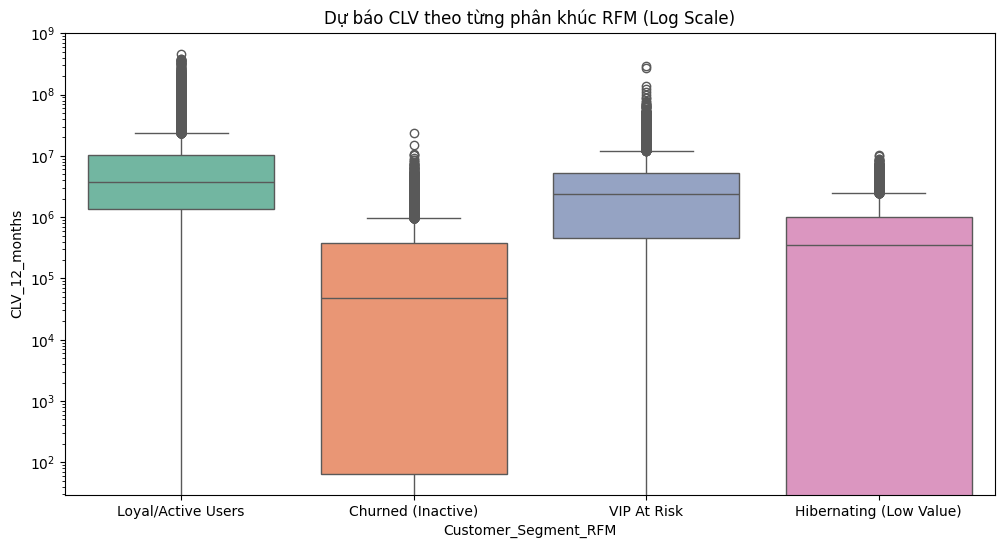

In [5]:
# 5. Tính CLV (Customer Lifetime Value)

# Dự báo CLV cho 12 tháng tới (52 tuần)
# discount_rate: Tỷ lệ chiết khấu dòng tiền (0.01 = 1% mỗi tháng ~ 12%/năm)
df['CLV_12_months'] = ggf.customer_lifetime_value(
    bgf,
    df['frequency_cal'],
    df['recency_weeks'],
    df['T_weeks'],
    df['monetary_value'],
    time=12, # Tính cho 12 tháng
    freq='M', # Đơn vị thời gian của 'time' là Month
    discount_rate=0.01
)

# Phân nhóm khách hàng theo CLV
df['CLV_Segment'] = pd.qcut(df['CLV_12_months'], q=3, labels=['Low Value', 'Mid Value', 'High Value'])

print("--- Phân phối giá trị khách hàng tương lai (CLV) ---")
print(df['CLV_Segment'].value_counts())

# Vẽ biểu đồ so sánh CLV giữa các nhóm RFM cũ
plt.figure(figsize=(12, 6))
sns.boxplot(x='Customer_Segment_RFM', y='CLV_12_months', data=df, palette='Set2')
plt.yscale('log') # Dùng thang log vì chênh lệch tiền rất lớn
plt.title('Dự báo CLV theo từng phân khúc RFM (Log Scale)')
plt.show()

In [6]:
# 6. Lưu kết quả
cols_to_save = [
    'id', 'full_name', 'created_date', 'last_active_date',
    'Customer_Segment_RFM', # Segment cũ (Quá khứ)
    'CLV_12_months', 'CLV_Segment', # Segment mới (Tương lai)
    'predicted_purchases_12weeks',
    'age', 'credit_sco', 'exit', 'risk_score', 'occupation', 'nums_service' # Giữ lại features gốc
]

df[cols_to_save].to_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_clv.csv', index=False)
print("Đã lưu file: processed_bank_data_clv.csv")

Đã lưu file: processed_bank_data_clv.csv
